# Chapter 4 Applied

In [183]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots 
import statsmodels.api as sm 
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                        summarize)

In [184]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
                    (LinearDiscriminantAnalysis as LDA ,
                     QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [185]:
Weekly = load_data("Weekly")
Weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


In [186]:
Weekly.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [187]:
Weekly.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


Text(0.5, 0.98, 'Stuff')

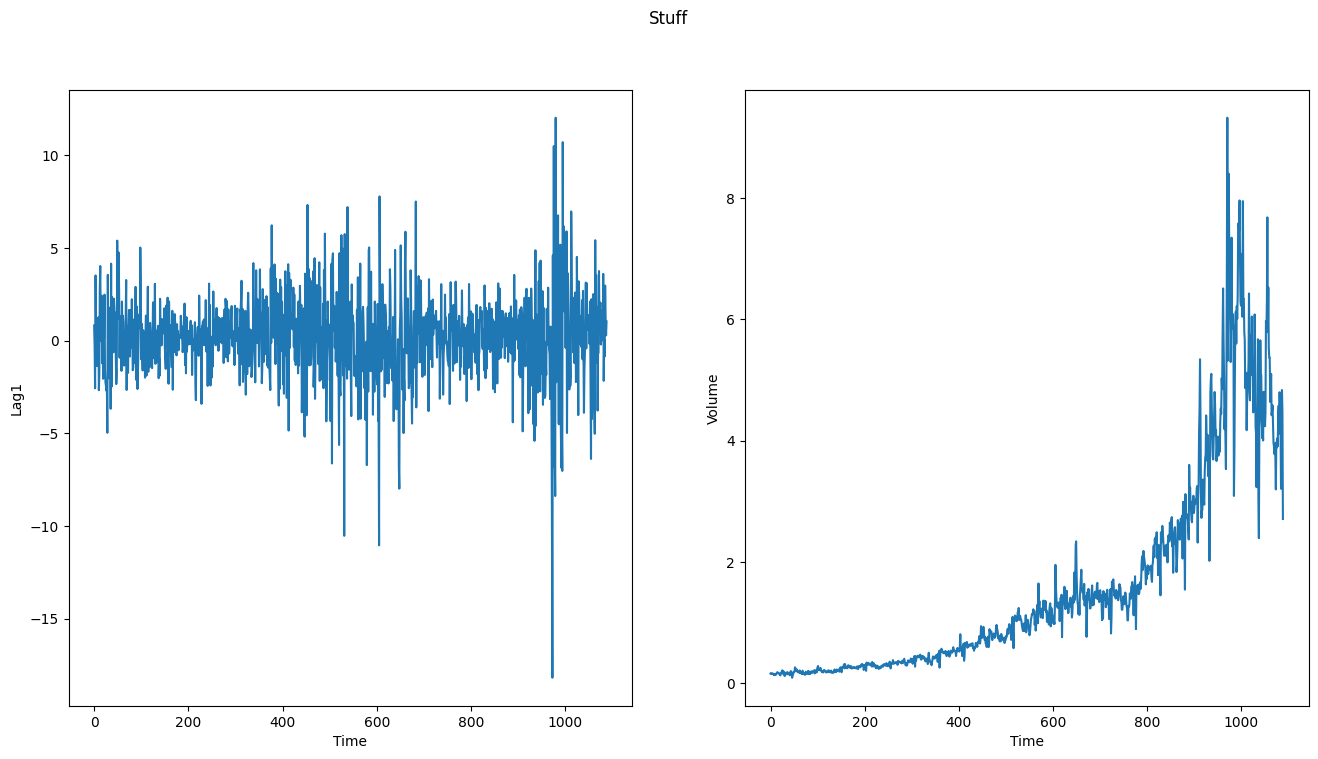

In [188]:
fig, (ax_lag, ax_vol) = subplots(1,2, figsize=(16,8))
ax_lag.plot(Weekly[['Lag1']])
ax_lag.set_xlabel("Time")
ax_lag.set_ylabel("Lag1")

ax_vol.plot(Weekly['Volume'])
ax_vol.set_xlabel("Time")
ax_vol.set_ylabel("Volume")

fig.suptitle("Stuff")


In [189]:
allvars = Weekly.columns.drop(['Year', 'Direction', 'Today'])
design = MS(allvars)
X = design.fit_transform(Weekly)
y = Weekly.Direction == 'Up'
glm = sm.GLM(y,
             X,
             family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,0.2669,0.086,3.106,0.002
Lag1,-0.0413,0.026,-1.563,0.118
Lag2,0.0584,0.027,2.175,0.030
Lag3,-0.0161,0.027,-0.602,0.547
Lag4,-0.0278,0.026,-1.050,0.294
Lag5,-0.0145,0.026,-0.549,0.583
Volume,-0.0227,0.037,-0.616,0.538


In [190]:
probs = results.predict()
probs

array([0.60862494, 0.60103144, 0.58756995, ..., 0.57972297, 0.55091703,
       0.52212163], shape=(1089,))

In [191]:
labels = np.array(['Down']*1089)
labels[probs > 0.5] = "Up"

In [192]:
confusion_table(labels, Weekly.Direction)

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [193]:
np.mean(labels == Weekly.Direction)

np.float64(0.5610651974288338)

In [194]:
train = (Weekly.Year < 2009)
Weekly_train = Weekly.loc[train]
Weekly_test = Weekly.loc[~train]
Weekly_test.shape

(104, 9)

In [195]:
X_hat = X[['intercept', 'Lag2']]
X_hat

,intercept,Lag2
0,1.0,1.572
1,1.0,0.816
2,1.0,-0.270
3,1.0,-2.576
4,1.0,3.514
...,...,...
1084,1.0,0.043
1085,1.0,-0.861
1086,1.0,2.969
1087,1.0,1.281


In [196]:
X_train, X_test = X_hat.loc[train], X_hat.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train,
                   X_train,
                   family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)
summarize(results)

,coef,std err,z,P>|z|
intercept,0.2033,0.064,3.162,0.002
Lag2,0.0581,0.029,2.024,0.043


In [197]:
D = Weekly.Direction
D_train, D_test = D.loc[train], D.loc[~train]

In [198]:
labels = np.array(['Down']*104)
labels[probs > 0.5] = 'Up'
confusion_table(labels, D_test)

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [199]:
np.mean(labels == D_test)

np.float64(0.625)

# Part e
Linear Discriminant Analysis

In [200]:
lda = LDA(store_covariance=True)

In [201]:
X_train, X_test = [M.drop(columns='intercept') 
                   for M in [X_train, X_test]]
lda.fit(X_train, D_train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",True
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [202]:
lda.means_

array([[-0.03568254],
       [ 0.26036581]])

In [203]:
lda.classes_

array(['Down', 'Up'], dtype='<U4')

In [204]:
lda_pred = lda.predict(X_test)

In [205]:
confusion_table(lda_pred, D_test)

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [206]:
lda_prob = lda.predict_proba(X_test)
np.all(
    np.where(lda_prob[:,1] >= 0.5, 'Up', 'Down') == lda_pred
)

np.True_

In [207]:
np.all(
    [lda.classes_[i] for i in np.argmax(lda_prob, 1)] == lda_pred
)

np.True_

In [208]:
np.sum(lda_prob[:,0] > 0.54)

np.int64(3)

# Part f QDA 


In [209]:
X_train_qda = X_hat.drop(columns='intercept').loc[train]
X_test_qda = X_hat.drop(columns='intercept').loc[~train]

qda = QDA(store_covariance=True)
qda.fit(X_train_qda, D_train)

qda_pred = qda.predict(X_test_qda)
confusion_table(qda_pred, D_test)

Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


In [210]:
np.mean(qda_pred == D_test)

np.float64(0.5865384615384616)

In [211]:
qda.covariance_[0]

array([[4.83781758]])

# KNN 

In [212]:
X_train_knn = X_hat.drop(columns='intercept').loc[train]
X_test_knn = X_hat.drop(columns='intercept').loc[~train]

knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_knn, D_train)

knn1_pred = knn1.predict(X_test_knn)
confusion_table(knn1_pred, D_test)

Truth,Down,Up
Predicted,,
Down,21,30
Up,22,31


In [213]:
np.mean(knn1_pred == D_test)

np.float64(0.5)